## Import

In [17]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

OUTPUT_DIR = r"D:\Đồ án\Recommentation_test\save_recommend_model\\"

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Load data

In [18]:
customer_product = pd.read_csv(r"D:\Đồ án\Recommentation_test\Data\CUS_X_PD.csv")
customer_cluster = pd.read_csv(r"D:\Đồ án\Recommentation_test\Data\CREDIT_USE_CUSTOMER.csv")
product          = pd.read_csv(r"D:\Đồ án\Recommentation_test\Data\DIM_PRODUCT.csv")
pd_x_cmpn        = pd.read_csv(r"D:\Đồ án\Recommentation_test\Data\PD_X_CMPN.csv")
dim_cmpn         = pd.read_csv(r"D:\Đồ án\Recommentation_test\Data\DIM_CMPN.csv")   

print(f"   customer_product : {customer_product.shape}")
print(f"   customer_cluster : {customer_cluster.shape}")
print(f"   product          : {product.shape}")
print(f"   pd_x_cmpn        : {pd_x_cmpn.shape}")
print(f"   dim_cmpn         : {dim_cmpn.shape}")

   customer_product : (39528, 3)
   customer_cluster : (8953, 19)
   product          : (42, 8)
   pd_x_cmpn        : (174, 6)
   dim_cmpn         : (39, 8)


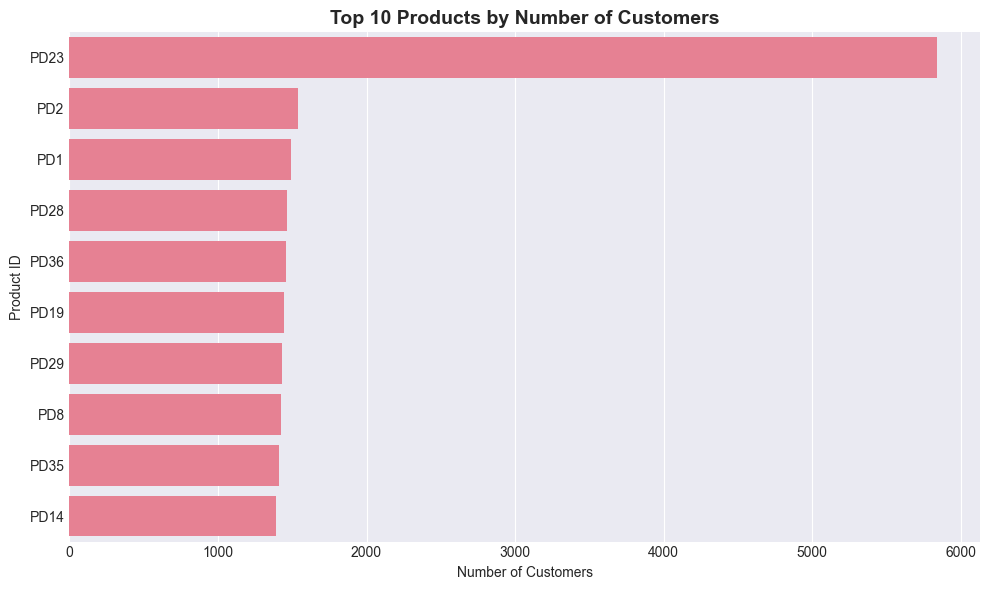

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Top 10 sản phẩm có nhiều khách hàng mua nhất
top_products = (
    customer_product
    .groupby('ID_PRODUCT')['CUS_ID']
    .nunique()
    .reset_index(name='NUM_CUSTOMERS')
    .sort_values(by='NUM_CUSTOMERS', ascending=False)
    .head(10)
)

# Vẽ biểu đồ
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products,
    x='NUM_CUSTOMERS',
    y='ID_PRODUCT'
)

plt.title('Top 10 Products by Number of Customers', fontsize=14, weight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Product ID')

plt.tight_layout()
plt.show()

## EDA: Data Overview

## Prepocessing

In [19]:
customer_product = (
    customer_product[['CUS_ID', 'ID_PRODUCT', 'VALUE']]
    .groupby(['CUS_ID', 'ID_PRODUCT'], as_index=False)['VALUE']
    .sum()
)

customer_cluster = (
    customer_cluster[['CUS_ID', 'SEGMENT']]
    .rename(columns={'SEGMENT': 'cluster'})
)

product = product[['PD_DIM', 'PD_CODE', 'PD_NAME']].dropna(subset=['PD_DIM', 'PD_CODE'])

dim_cmpn         = dim_cmpn[['CMPN_DIM_ID','CMPN_CODE','CMPN_NAME','CMPN_DES']]
pd_x_cmpn_active = pd_x_cmpn[['PD_DIM_ID','CMPN_DIM_ID']].copy()

pd_dim_to_code   = dict(zip(product['PD_DIM'].astype(int), product['PD_CODE'].str.lower()))
pd_x_cmpn_active['PD_CODE_lower'] = pd_x_cmpn_active['PD_DIM_ID'].map(pd_dim_to_code)


## User-Item matrix

In [20]:
customer_product_matrix = customer_product.pivot_table(
    index='CUS_ID',
    columns='ID_PRODUCT',
    values='VALUE',
    aggfunc='sum',
    fill_value=0
)
product_cols  = customer_product_matrix.columns.tolist()
customer_ids  = customer_product_matrix.index.tolist()
matrix_values = customer_product_matrix.values

print(f"User-Item matrix: {customer_product_matrix.shape}")

User-Item matrix: (8951, 37)


## EDA: User-Item Matrix Analysis

## TF-IDF: Vectorize the spending behavior of each customer.

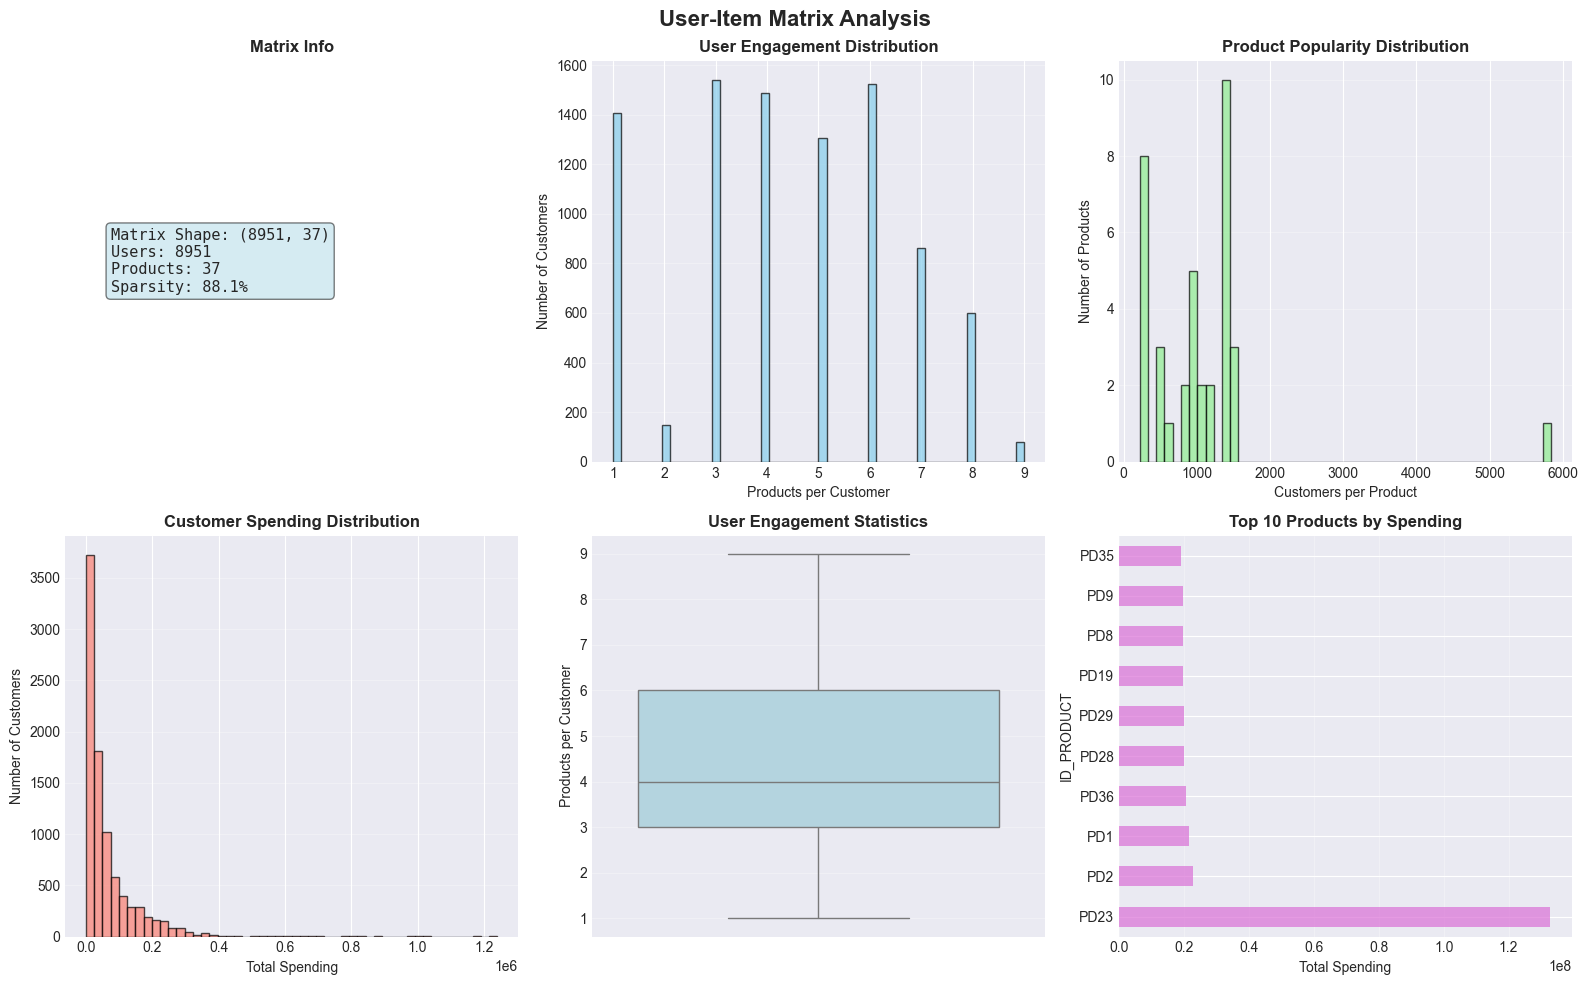


=== USER-ITEM MATRIX SUMMARY ===
Shape: (8951, 37) | Sparsity: 88.07%
User engagement: count    8951.000000
mean        4.410792
std         2.114079
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000

Product popularity: count      37.000000
mean     1067.054054
std       929.383874
min       222.000000
25%       466.000000
50%       984.000000
75%      1392.000000
max      5838.000000

Spending per user: count    8.951000e+03
mean     6.399904e+04
std      8.570060e+04
min      1.500000e+02
25%      1.160000e+04
50%      3.295000e+04
75%      7.988750e+04
max      1.239925e+06


In [21]:
# User-Item Matrix EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('User-Item Matrix Analysis', fontsize=16, fontweight='bold')

# 1. Matrix basic info
ax = axes[0, 0]
sparsity = (customer_product_matrix == 0).sum().sum() / (customer_product_matrix.shape[0] * customer_product_matrix.shape[1])
info_text = f"Matrix Shape: {customer_product_matrix.shape}\nUsers: {customer_product_matrix.shape[0]}\nProducts: {customer_product_matrix.shape[1]}\nSparsity: {sparsity:.1%}"
ax.text(0.1, 0.5, info_text, fontsize=11, verticalalignment='center', family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Matrix Info', fontweight='bold')

# 2. User engagement distribution
ax = axes[0, 1]
user_engagement = (customer_product_matrix > 0).sum(axis=1)
ax.hist(user_engagement, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Products per Customer')
ax.set_ylabel('Number of Customers')
ax.set_title('User Engagement Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 3. Product popularity distribution
ax = axes[0, 2]
product_popularity = (customer_product_matrix > 0).sum(axis=0)
ax.hist(product_popularity, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax.set_xlabel('Customers per Product')
ax.set_ylabel('Number of Products')
ax.set_title('Product Popularity Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 4. Spending per user
ax = axes[1, 0]
spending_per_user = customer_product_matrix.sum(axis=1)
ax.hist(spending_per_user, bins=50, color='salmon', edgecolor='black', alpha=0.7)
ax.set_xlabel('Total Spending')
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Spending Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 5. User engagement box plot
ax = axes[1, 1]
sns.boxplot(y=user_engagement, ax=ax, color='lightblue')
ax.set_ylabel('Products per Customer')
ax.set_title('User Engagement Statistics', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 6. Top 10 products by spending
ax = axes[1, 2]
top_products = customer_product_matrix.sum(axis=0).nlargest(10)
top_products.plot(kind='barh', ax=ax, color='orchid', alpha=0.7)
ax.set_xlabel('Total Spending')
ax.set_title('Top 10 Products by Spending', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"\n=== USER-ITEM MATRIX SUMMARY ===")
print(f"Shape: {customer_product_matrix.shape} | Sparsity: {sparsity:.2%}")
print(f"User engagement: {user_engagement.describe().to_string()}")
print(f"\nProduct popularity: {product_popularity.describe().to_string()}")
print(f"\nSpending per user: {spending_per_user.describe().to_string()}")

In [7]:
def row_to_text(row, col_names):
    tokens = []
    for val, name in zip(row, col_names):
        if val > 0:
            tokens.extend([name] * max(1, int(round(val))))
    return " ".join(tokens) if tokens else "UNKNOWN"

customer_texts = [row_to_text(matrix_values[i], product_cols) for i in range(len(matrix_values))]

tfidf        = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
tfidf_matrix = tfidf.fit_transform(customer_texts)
tfidf_vocab  = tfidf.get_feature_names_out().tolist()

product_cols_lower   = [p.lower() for p in product_cols]
product_feature_cols = [c for c in tfidf_vocab if c in product_cols_lower]

print(f" TF-IDF matrix        : {tfidf_matrix.shape}")
print(f"   Product feature cols : {len(product_feature_cols)} category")

# PKL 1
with open(OUTPUT_DIR + "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

 TF-IDF matrix        : (8951, 37)
   Product feature cols : 37 category


## EDA: TF-IDF Vectorization Analysis

## Customer profile vectors

C:\Users\Surface\AppData\Local\Temp\ipykernel_8496\2328299887.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tfidf_values], labels=['TF-IDF Score'])


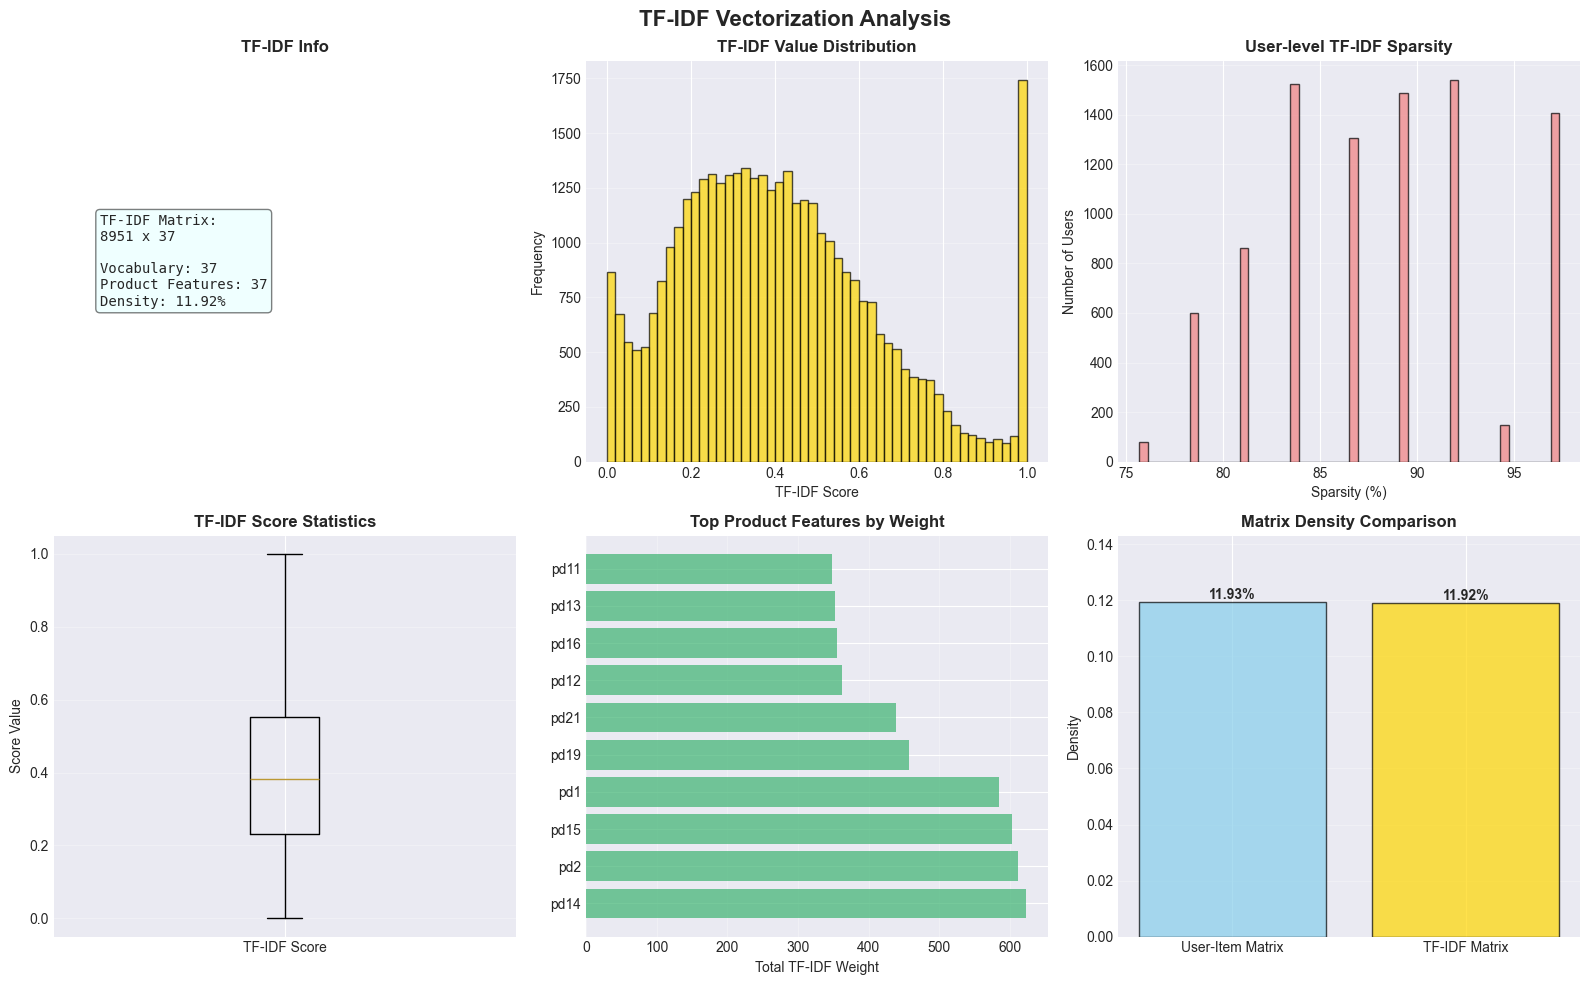


=== TF-IDF TRANSFORMATION SUMMARY ===
TF-IDF Matrix Shape: (8951, 37) | Density: 11.92%
Vocabulary Size: 37 | Product Features: 37
TF-IDF Value Stats - Min: 0.0001, Max: 1.0000, Mean: 0.4110
User Sparsity - Min: 75.68%, Max: 97.30%, Mean: 88.08%


In [22]:
# TF-IDF Vectorization EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('TF-IDF Vectorization Analysis', fontsize=16, fontweight='bold')

# 1. TF-IDF matrix info
ax = axes[0, 0]
tfidf_density = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
info_text = f"TF-IDF Matrix:\n{tfidf_matrix.shape[0]} x {tfidf_matrix.shape[1]}\n\nVocabulary: {len(tfidf_vocab)}\nProduct Features: {len(product_feature_cols)}\nDensity: {tfidf_density:.2%}"
ax.text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center', family='monospace', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('TF-IDF Info', fontweight='bold')

# 2. TF-IDF values distribution
ax = axes[0, 1]
tfidf_values = tfidf_matrix.data
ax.hist(tfidf_values, bins=50, color='gold', edgecolor='black', alpha=0.7)
ax.set_xlabel('TF-IDF Score')
ax.set_ylabel('Frequency')
ax.set_title('TF-IDF Value Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 3. User sparsity after TF-IDF
ax = axes[0, 2]
user_tfidf_sparsity = (tfidf_matrix.toarray() == 0).sum(axis=1) / tfidf_matrix.shape[1]
ax.hist(user_tfidf_sparsity * 100, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Sparsity (%)')
ax.set_ylabel('Number of Users')
ax.set_title('User-level TF-IDF Sparsity', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 4. TF-IDF statistics box plot
ax = axes[1, 0]
ax.boxplot([tfidf_values], labels=['TF-IDF Score'])
ax.set_ylabel('Score Value')
ax.set_title('TF-IDF Score Statistics', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 5. Top product features frequency
ax = axes[1, 1]
feature_counts = np.array([tfidf_matrix[:, tfidf_vocab.index(f)].sum() for f in product_feature_cols[:15]])
top_features = sorted(zip(product_feature_cols[:15], feature_counts), key=lambda x: x[1], reverse=True)[:10]
features, counts = zip(*top_features)
ax.barh(range(len(features)), counts, color='mediumseagreen', alpha=0.7)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features)
ax.set_xlabel('Total TF-IDF Weight')
ax.set_title('Top Product Features by Weight', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 6. Matrix density comparison
ax = axes[1, 2]
matrix_density = 1 - sparsity
densities = [matrix_density, tfidf_density]
labels = ['User-Item Matrix', 'TF-IDF Matrix']
colors = ['skyblue', 'gold']
bars = ax.bar(labels, densities, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Density')
ax.set_title('Matrix Density Comparison', fontweight='bold')
ax.set_ylim(0, max(densities) * 1.2)
for bar, density in zip(bars, densities):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{density:.2%}', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print key stats
print(f"\n=== TF-IDF TRANSFORMATION SUMMARY ===")
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape} | Density: {tfidf_density:.2%}")
print(f"Vocabulary Size: {len(tfidf_vocab)} | Product Features: {len(product_feature_cols)}")
print(f"TF-IDF Value Stats - Min: {tfidf_values.min():.4f}, Max: {tfidf_values.max():.4f}, Mean: {tfidf_values.mean():.4f}")
print(f"User Sparsity - Min: {user_tfidf_sparsity.min():.2%}, Max: {user_tfidf_sparsity.max():.2%}, Mean: {user_tfidf_sparsity.mean():.2%}")

In [9]:

customer_profile_vectors = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=customer_ids,
    columns=tfidf_vocab
)
customer_profile_vectors.index.name = 'CUS_ID'

# PKL 2
with open(OUTPUT_DIR + "customer_profile_vectors.pkl", "wb") as f:
    pickle.dump(customer_profile_vectors, f)
print(f"SAVE customer_profile_vectors.pkl → shape: {customer_profile_vectors.shape}")

SAVE customer_profile_vectors.pkl → shape: (8951, 37)


## Segment vectors (cluster centroid)

In [10]:
tfidf_cluster_df = (
    customer_cluster.set_index('CUS_ID')
    .join(customer_profile_vectors, how='left')
    .reset_index()
)
tfidf_cluster_df['cluster'] = tfidf_cluster_df['cluster'].fillna(-1).astype(int)
segment_vecs = tfidf_cluster_df.groupby('cluster')[product_feature_cols].mean()

# PKL 3
with open(OUTPUT_DIR + "segment_vecs.pkl", "wb") as f:
    pickle.dump(segment_vecs, f)
print(f"{segment_vecs.shape}")
print(f"   Clusters: {segment_vecs.index.tolist()}")

(6, 37)
   Clusters: [0, 1, 2, 3, 4, 5]


## KM Vectors (Promotion vectors)

Đoạn code xây dựng vector đại diện cho từng chương trình khuyến mãi bằng cách tổng hợp hành vi chi tiêu của khách hàng trên các sản phẩm thuộc chương trình đó. Vector của chương trình được tạo từ trung bình có trọng số của các vector khách hàng, trong đó trọng số dựa trên mức chi tiêu, giúp chương trình phản ánh đặc điểm của nhóm khách hàng thực tế sử dụng nó.

In [ ]:



km_vecs_list = []
km_ids_list  = []

for cmpn_id in sorted(pd_x_cmpn_active['CMPN_DIM_ID'].unique()):
    # Expenditure categories under this program
    pds_in_km = (
        pd_x_cmpn_active[pd_x_cmpn_active['CMPN_DIM_ID'] == cmpn_id]['PD_CODE_lower']
        .dropna().tolist()
    )
    pds_in_km = [p for p in pds_in_km if p in product_feature_cols]
    if not pds_in_km:
        continue

    # The customer has used at least one item from this program.
  
  
    pd_upper  = [p.upper() for p in pds_in_km]
    km_txn    = customer_product[customer_product['ID_PRODUCT'].isin(pd_upper)]

    if km_txn.empty:
        # Fallback: one-hot uniform
        vec    = np.zeros(len(product_feature_cols))
        pf_idx = {c: i for i, c in enumerate(product_feature_cols)}
        for p in pds_in_km:
            if p in pf_idx:
                vec[pf_idx[p]] = 1.0 / len(pds_in_km)
    else:
        # Weight = total value that customers spend on items included in the program
        cus_weights = km_txn.groupby('CUS_ID')['VALUE'].sum()
        cus_weights = cus_weights[cus_weights.index.isin(customer_profile_vectors.index)]
        if cus_weights.empty:
            continue
        cus_weights = cus_weights / cus_weights.sum()

        buyer_vecs = customer_profile_vectors.loc[cus_weights.index, product_feature_cols]
        w_vals     = cus_weights.values.reshape(-1, 1)
        vec        = (buyer_vecs.values * w_vals).sum(axis=0)

    km_vecs_list.append(vec)
    km_ids_list.append(cmpn_id)

km_vecs = pd.DataFrame(
    km_vecs_list,
    index=km_ids_list,
    columns=product_feature_cols
)

promo_meta = dim_cmpn.set_index('CMPN_DIM_ID')

print(f" Program vectors shape  : {km_vecs.shape}")
print(f"   CMPN have vector    : {len(km_ids_list)}")

# PKL 4
with open(OUTPUT_DIR + "program_vecs.pkl", "wb") as f:
    pickle.dump({'progream_vecs': km_vecs, 'promo_meta': promo_meta}, f)
print("SAVE program_vecs.pkl")

 Program vectors shape  : (38, 37)
   CMPN have vector    : 38
SAVE program_vecs.pkl


## PROMOTION RECOMMENDATION FUNCTION

Hàm recommend_promotions() thực hiện gợi ý chương trình khuyến mãi cho khách hàng bằng cách kết hợp giữa business rule và similarity-based recommendation. Đầu tiên, hệ thống xác định cluster của khách hàng và lấy vector hành vi tương ứng để tính cosine similarity với các vector chương trình khuyến mãi. Sau đó, các campaign ưu tiên theo chiến lược kinh doanh của từng cluster sẽ được đưa lên đầu danh sách, tiếp theo là các campaign có độ tương đồng cao nhất với sở thích và hành vi chi tiêu của khách hàng nhằm tăng mức độ cá nhân hóa của hệ thống gợi ý.

In [12]:
CLUSTER_PRIORITY_CAMPAIGNS = {
    1: [1000037, 1000038],  # Cluster ngủ đông → Khảo sát + Tái kích hoạt
}

def recommend_promotions(customer_id, top_n=None, similarity_threshold=0.5):
    row = customer_cluster[customer_cluster['CUS_ID'] == customer_id]
    cluster_id = int(row['cluster'].values[0]) if not row.empty else -1

    if customer_id in customer_profile_vectors.index:
        cus_vec = customer_profile_vectors.loc[customer_id, product_feature_cols].values.reshape(1, -1)
    else:
        if cluster_id in segment_vecs.index:
            cus_vec = segment_vecs.loc[cluster_id].values.reshape(1, -1)
        else:
            return pd.DataFrame()

    sims = cosine_similarity(cus_vec, km_vecs.values)[0]
    sim_series = pd.Series(sims, index=km_ids_list).sort_values(ascending=False)

    if top_n is not None:
        top_sim = sim_series.head(top_n)
    else:
        top_sim = sim_series[sim_series > similarity_threshold]

    rows = []
    rank = 1

    # ✅ Business rule lên TOP trước, rank 1, 2, ...
    if cluster_id in CLUSTER_PRIORITY_CAMPAIGNS:
        for cmpn_id in CLUSTER_PRIORITY_CAMPAIGNS[cluster_id]:
            if cmpn_id in promo_meta.index:
                rows.append({
                    'CUS_ID'      : customer_id,
                    'SEGMENT'     : cluster_id,
                    'CMPN_DIM_ID' : cmpn_id,
                    'similarity'  : None,
                    'rank'        : rank,
                    'note'        : 'business_rule'
                })
                rank += 1

    # ✅ Similarity-based tiếp theo, rank nối tiếp
    priority_ids_set = set(CLUSTER_PRIORITY_CAMPAIGNS.get(cluster_id, []))
    for cmpn_id, sim in top_sim.items():
        if cmpn_id in promo_meta.index and cmpn_id not in priority_ids_set:
            rows.append({
                'CUS_ID'      : customer_id,
                'SEGMENT'     : cluster_id,
                'CMPN_DIM_ID' : int(cmpn_id),
                'similarity'  : round(float(sim), 4),
                'rank'        : rank,
                'note'        : 'similarity_based'
            })
            rank += 1

    return pd.DataFrame(rows)

## RUN ALL CUSTOMERS AND RECOMMENDATION_PROGRAMS.csv

In [13]:
print("\n Run all customers...")
all_recs = []
all_ids  = customer_cluster['CUS_ID'].unique()

for i, cus_id in enumerate(all_ids):
    r = recommend_promotions(cus_id, top_n=None, similarity_threshold=0.5)
    if not r.empty:
        all_recs.append(r)
    if (i + 1) % 1000 == 0:
        print(f"  [{i+1:,}/{len(all_ids):,}]...")

result_df = pd.concat(all_recs, ignore_index=True)

print(f"\n TOTAL RESULTS: {result_df.shape}")

out_path = r"D:\Đồ án\Recommentation_test\data\RECOMMENDATION_PROGRAMS.csv"
result_df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"\n EXPORT: {out_path}")


 Run all customers...
  [1,000/8,953]...
  [2,000/8,953]...
  [3,000/8,953]...
  [4,000/8,953]...
  [5,000/8,953]...
  [6,000/8,953]...
  [7,000/8,953]...
  [8,000/8,953]...


C:\Users\Surface\AppData\Local\Temp\ipykernel_8496\2508154249.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat(all_recs, ignore_index=True)



 TOTAL RESULTS: (65222, 6)

 EXPORT: D:\Đồ án\Recommentation_test\data\RECOMMENDATION_PROGRAMS.csv


## SAVE MODEL

In [14]:
import os
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith('.pkl'):
        size = os.path.getsize(OUTPUT_DIR + fname) / 1024
        print(f"   {fname:<45} {size:>8.1f} KB")

   customer_profile_vectors.pkl                    2658.2 KB
   km_vecs.pkl                                       21.1 KB
   program_vecs.pkl                                  21.1 KB
   segment_vecs.pkl                                   2.6 KB
   tfidf_vectorizer.pkl                               1.9 KB


## MERGE BRANCH INTO FCT_CREDIT_USE_CUSTOMER

In [15]:
import pandas as pd

fct = pd.read_csv(r"D:\Đồ án\Recommentation_test\Data\CREDIT_USE_CUSTOMER.csv")
cxb = pd.read_csv(r"D:\Đồ án\Recommentation_test\Data\CUS_X_BRN.csv")

cxb_unique = cxb[['CUS_ID', 'BRN_DIM_ID', 'SUB_BRN_DIM_ID']] \
    .drop_duplicates(subset='CUS_ID', keep='first')

cols_to_drop = ['BRN_DIM_ID', 'SUB_BRN_DIM_ID']
fct = fct.drop(columns=[col for col in cols_to_drop if col in fct.columns])

fct_enriched = fct.merge(cxb_unique, on='CUS_ID', how='left')

matched   = fct_enriched['BRN_DIM_ID'].notna().sum()
unmatched = fct_enriched['BRN_DIM_ID'].isna().sum()

out_path = r"D:\Đồ án\Recommentation_test\Data\CREDIT_USE_CUSTOMER.csv"
fct_enriched.to_csv(out_path, index=False, encoding='utf-8-sig')

print(f"\n SAVED: {out_path}")


 SAVED: D:\Đồ án\Recommentation_test\Data\CREDIT_USE_CUSTOMER.csv


In [26]:
fct_enriched.shape

(8953, 19)